### L shaped antenna simulation.

In this notebook we will generate the mesh of an L shaped antenna and generate a json for a transient
simulation.

In [1]:
import gmsh
import os
import json

from palacetoolkit.viz import run_with_scrollable_output, view_mesh
from palacetoolkit.mesh import (
    Entity, 
    run_meshing_pipeline, 
    generate_3d_mesh, 
    refine_near_surfaces
)


### Parameters:
- h : Patch height along z-axis, specified as a scalar in meters. 
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- w3 : Strip line width along y-axis, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [2]:
l1: float = 0.06
w1: float = 0.06
w3: float = 0.002
h: float = 0.0013
air_height: float = 0.025    
air_margin: float = 0.025    
freq: float = 3.3
mesh_file: str = "l_antenna.msh"


eps_r: float = 2.2
loss_tan: float = 0.0009

wavelength = 3e8 / (freq * 1e9)
mesh_size = wavelength / 15

### Initialize the model

In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ

### Geometry Construction


In [4]:
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height


# 1. Create volumes
substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)
air_box = kernel.addBox(total_xmin, total_ymin, 0,
                        total_xmax - total_xmin,
                        total_ymax - total_ymin,
                        total_zmax)
kernel.synchronize()

# 2. Create 2D surfaces (ground, patch, ports)
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

strip_length_x = l1/2
strip_length_y = w1/2 + w3/2

feed_line_x = kernel.addRectangle(-l1/2, -w3/2, h, strip_length_x, w3)
feed_line_y = kernel.addRectangle(0, -w3/2, h, w3, strip_length_y)

top_conductor, top_map = kernel.fuse(
    [(2, feed_line_x)], [(2, feed_line_y)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

# Lumped ports — build directly in-plane, no rotation
# Port 1: at x = -l1/2, vertical face
p1 = kernel.addPoint(-l1/2, -w3/2, 0)
p2 = kernel.addPoint(-l1/2,  w3/2, 0)
p3 = kernel.addPoint(-l1/2,  w3/2, h)
p4 = kernel.addPoint(-l1/2, -w3/2, h)

lp1_a = kernel.addLine(p1, p2)
lp1_b = kernel.addLine(p2, p3)
lp1_c = kernel.addLine(p3, p4)
lp1_d = kernel.addLine(p4, p1)
loop1 = kernel.addCurveLoop([lp1_a, lp1_b, lp1_c, lp1_d])
lumped_port_1 = kernel.addPlaneSurface([loop1])
kernel.synchronize()

# Port 2: at y = w1/2, vertical face
p5 = kernel.addPoint(0,  w1/2, 0)
p6 = kernel.addPoint(w3, w1/2, 0)
p7 = kernel.addPoint(w3, w1/2, h)
p8 = kernel.addPoint(0,  w1/2, h)

lp2_a = kernel.addLine(p5, p6)
lp2_b = kernel.addLine(p6, p7)
lp2_c = kernel.addLine(p7, p8)
lp2_d = kernel.addLine(p8, p5)
loop2 = kernel.addCurveLoop([lp2_a, lp2_b, lp2_c, lp2_d])
lumped_port_2 = kernel.addPlaneSurface([loop2])
kernel.synchronize()

# Define the entities which will be the physical groups.
entities = [
    Entity("substrate", dim = 3, mesh_order = 1, tags = [substrate]),
    Entity("air_box", dim = 3, mesh_order = 2, tags = [air_box]),
    Entity("top_conductor", dim = 2, mesh_order = 1, tags = [top_conductor[0][1]]),
    Entity("ground_plane", dim = 2, mesh_order = 1, tags = [ground_plane]),
    Entity("lumped_port_1", dim = 2, mesh_order = 0, tags = [lumped_port_1]),
    Entity("lumped_port_2", dim = 2, mesh_order = 0, tags = [lumped_port_2])
]


Info    : Cannot bind existing OpenCASCADE surface 14 to second tag 15
Info    : Could not preserve tag of 2D object 15 (->14)


In [5]:
pg_map = run_meshing_pipeline(entities)

lumped_port_1 = entities[-1].dimtags[0]
lumped_port_2 =  entities[-2].dimtags[0]

# Refine near the top conductor and also locally refine the ports.
refine_near_surfaces(entities[2].dimtags, 
                     wavelength, 
                     ppw_near=100, 
                     ppw_far=15, 
                     set_as_background=True,
                     local_refinements = {lumped_port_1: 100, lumped_port_2 : 100})

mesh_sizes = {
    "substrate": wavelength / 12,
    "air_box": wavelength / 4,
    "lumped_port_1": wavelength / 18,
    "lumped_port_2": wavelength / 18,
    "top_conductor": wavelength /10
}

def _generate_l_antenna_mesh():
    generate_3d_mesh(entities, mesh_sizes, mesh_file, optimize=True)
    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.write(mesh_file)

run_with_scrollable_output(_generate_l_antenna_mesh, title="L antenna mesh generation", max_lines=10)
gmsh.finalize()

  Physical group 'substrate' (dim=3): pg=1, tags=[1]
  Physical group 'air_box' (dim=3): pg=2, tags=[2]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[14]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[13]
  Physical group 'lumped_port_1' (dim=2): pg=5, tags=[15]
  Physical group 'lumped_port_2' (dim=2): pg=6, tags=[16]
  Physical group 'air_box__substrate' (dim=2): pg=7, tags=[17, 18, 19, 20, 21, 22, 23, 24]
  Physical group 'air_box__None' (dim=2): pg=8, tags=[25, 26, 27, 28, 29, 30]
  ppw_near=100  ppw_far=15
  SizeMax=0.0061  transition=0.0227
  global: 6 curves, SizeMin=0.0009
  local (2, 16): 4 curves, SizeMin=0.0009
  local (2, 15): 4 curves, SizeMin=0.0009
  Merged 3 fields with Min → field 7
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 40 (Line)
Info    : [ 10%] Meshing curve 44 (Line)
Info    : [ 10%] Meshing curve 45 (Line)
Info    : [ 10%] Meshing curve 46 (Line)
Info    : [ 20%] Meshing curve 47 (Line)
Info    : [ 20%] Meshing curve 48 (Line)
Info   

Info    : [ 90%] Meshing surface 29 (Plane, MeshAdapt)


Info    : [100%] Meshing surface 30 (Plane, MeshAdapt)
Info    : Done meshing 2D (Wall 0.126287s, CPU 0.125125s)
Info    : Meshing 3D...
Info    : 3D Meshing 2 volumes with 1 connected component
Info    : Tetrahedrizing 2835 nodes...
Info    : Done tetrahedrizing 2843 nodes (Wall 0.0303642s, CPU 0.028665s)
Info    : Reconstructing mesh...
Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.0705336s, CPU 0.063252s)
Info    : Found volume 2
Info    : Found volume 1
Info    : It. 0 - 0 nodes created - worst tet radius 8.01783 (nodes removed 0 0)
Info    : It. 500 - 500 nodes created - worst tet radius 1.45071 (nodes removed 0 0)


Info    : It. 1000 - 1000 nodes created - worst tet radius 1.18338 (nodes removed 0 0)


Info    : It. 1500 - 1500 nodes created - worst tet radius 1.04811 (nodes removed 0 0)
Info    : 3D refinement terminated (4619 nodes total):
Info    :  - 1 Delaunay cavities modified for star shapeness
Info    :  - 0 nodes could not be inserted
Info    :  - 22577 tetrahedra created in 0.100642 sec. (224330 tets/s)
Info    : 0 node relocations
Info    : Done meshing 3D (Wall 0.237991s, CPU 0.232911s)
Info    : Optimizing mesh...
Info    : Optimizing volume 1
Info    : Optimization starts (volume = 4.68e-06) with worst = 0.0427981 / average = 0.739068:
Info    : 0.00 < quality < 0.10 :        11 elements
Info    : 0.10 < quality < 0.20 :        28 elements
Info    : 0.20 < quality < 0.30 :        66 elements
Info    : 0.30 < quality < 0.40 :       148 elements
Info    : 0.40 < quality < 0.50 :       314 elements
Info    : 0.50 < quality < 0.60 :       325 elements
Info    : 0.60 < quality < 0.70 :       588 elements
Info    : 0.70 < quality < 0.80 :      1070 elements
Info    : 0.80 < q

...

Info    : 0 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 23033.6 
Info    : Total badness = 23023.9 
Info    : SwapImprove  
Info    : 236 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 22859.6 
Info    : Total badness = 22711.8 
Info    : CombineImprove 


Info    : 7 elements combined 
Info    : ImproveMesh 
Info    : Total badness = 22648.6 


Info    : Total badness = 22633.5 
Info    : SplitImprove 
Info    : badmax = 14.613 
Info    : 0 splits performed 
Info    : ImproveMesh 
Info    : Total badness = 22633.5 
Info    : Total badness = 22631.1 
Info    : SwapImprove  
Info    : 84 swaps performed 
Info    : SwapImprove2  
Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 22573 
Info    : Total badness = 22519.4 
Info    : Done optimizing mesh (Wall 1.17396s, CPU 1.18128s)
Info    : Writing 'l_antenna.msh'...


Info    : Done writing 'l_antenna.msh'
Info    : Writing 'l_antenna.msh'...


Info    : Done writing 'l_antenna.msh'


Loading mesh file: l_antenna.msh
Groups to render transparent: air_box__None

Mesh loaded successfully with 2 cell blocks
Found 5730 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port_1', 6: 'lumped_port_2', 7: 'air_box__substrate', 8: 'air_box__None'}



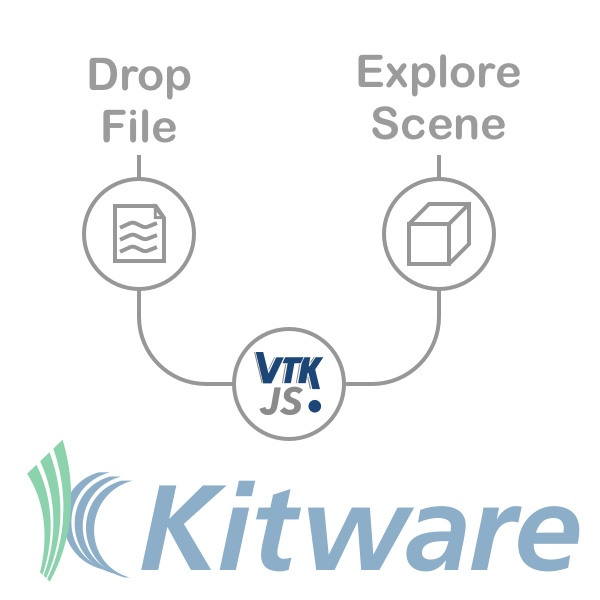

In [6]:
view_mesh(mesh_file, transparent_groups= "air_box__None")

### Simulation Configuration
We define the key parameters for the electromagnetic simulation here. These settings control the frequency sweep range, material properties (dielectric constant and loss tangent for the substrate), and solver-specific configurations like port impedance and mesh order.

- output_file  : output filename for the configuration JSON file
- freq : frequency for the simulation (GHz)  
- eps_r: relative permittivity of the substrate
- loss_tan: loss tangent of the substrate
- port_impedance: characteristic impedance of the lumped port (Ohms)
- solver_order: order of the finite element basis functions for the simulation (e.g., 1 for linear, 2 for quadratic)

In [7]:
output_file_transient: str = "l_antenna_transient.json"
output_file_driven: str = "l_antenna_driven.json"

freq: float = 3.16
eps_r: float = 2.2
loss_tan: float = 0.0009
port_impedance: float = 50.0
solver_order: int = 2


import numpy as np
eps_0 = 8.8541878128e-12
sigma = 2 * np.pi * freq * eps_0 * eps_r * loss_tan

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into two JSON configuration. One for a transient simulation and one for a driven where we check the s-parameters.

In [8]:
def attr(name):
        return [pg_map[name]] if name in pg_map else []

config = {
    "Problem": {
        "Type": "Transient",
        "Verbose": 2,
        "Output": "/work/results_transient/l_antenna/"
    },

    "Model": {
        "Mesh": f"/work/{mesh_file}",
        "L0": 1.0,
        "Refinement": {}
    },

    "Domains": {
    "Materials": [
        {
            "Attributes": attr("substrate"),
            "Permittivity": eps_r,
            "Permeability": 1.0,
            "Conductivity": sigma  # Replaced LossTan
        },
        {
            "Attributes": attr("air"),
            "Permittivity": 1.0,
            "Permeability": 1.0
        }
    ]
},

    "Boundaries": {
        "PEC": {
            "Attributes": attr("ground_plane") + attr("patch")
        },

        "LumpedPort": [
            {
                "Index": 1,
                "Attributes": attr("lumped_port_1"),
                "R": port_impedance,
                "Excitation": True,
                "Direction":  [0.0, 0.0, 1.0]
            },
            {
                "Index": 2,
                "Attributes": attr("lumped_port_2"),
                "R": port_impedance,
                "Excitation": False,              
                "Direction": [0.0, 0.0, 1.0]     
            }
        ],

        "Absorbing": {
            "Attributes": attr("farfield"),
            "Order": 1
        }
    },

    "Solver": {
    "Order": solver_order,
    "Device": "CPU",
    "Transient": {
      "Type": "GeneralizedAlpha",
      "Excitation": "ModulatedGaussian",
      "ExcitationFreq": freq, 
      "ExcitationWidth": 0.05, 
      "MaxTime": 1.0, 
      "TimeStep": 0.005, 
      "SaveStep": 10
    },
    "Linear": {
      "Type": "AMS",
      "KSPType": "CG",
      "Tol": 1.0e-8,
      "MaxIts": 100
    }
  }
}



script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file_transient)
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Palace config written to {config_path}")

Palace config written to /home/martin/Desktop/PalaceToolkit/docs/examples/l_antenna_transient.json


In [9]:
config = {
    "Problem": {
        "Type": "Driven",
        "Verbose": 2,
        "Output": "/work/results_driven/l_antenna/"
    },

    "Model": {
        "Mesh": f"/work/{mesh_file}",
        "L0": 1.0,
        "Refinement": {}
    },

    "Domains": {
    "Materials": [
        {
            "Attributes": attr("substrate"),
            "Permittivity": eps_r,
            "Permeability": 1.0,
            "Conductivity": loss_tan 
        },
        {
            "Attributes": attr("air"),
            "Permittivity": 1.0,
            "Permeability": 1.0
        }
    ]
},

    "Boundaries": {
        "PEC": {
            "Attributes": attr("ground_plane") + attr("patch")
        },

        "LumpedPort": [
            {
                "Index": 1,
                "Attributes": attr("lumped_port_1"),
                "R": port_impedance,
                "Excitation": True,
                "Direction":  [0.0, 0.0, 1.0]
            },
            {
                "Index": 2,
                "Attributes": attr("lumped_port_2"),
                "R": port_impedance,
                "Excitation": False,              
                "Direction": [0.0, 0.0, 1.0]     
            }
        ],

        "Absorbing": {
            "Attributes": attr("farfield"),
            "Order": 1
        }
    },

  "Solver": {
    "Order": 2,
    "Device": "CPU",
    "Driven": {
      "MinFreq": 3.0,
      "MaxFreq": 3.5,
      "FreqStep": 0.1,
      "SaveStep": 1,
      "AdaptiveTol": 0.0001
    },
    "Linear": {
      "Type": "Default",
      "KSPType": "GMRES",
      "Tol": 1e-08,
      "MaxIts": 300,
      "MaxSize": 1000,
      "ComplexCoarseSolve": True
    }
  }
}



script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file_driven)
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Palace config written to {config_path}")

Palace config written to /home/martin/Desktop/PalaceToolkit/docs/examples/l_antenna_driven.json
